In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import MassBalance, Albedo 
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
from get_ddf import get_ddf_df 
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K14k','K17b'],
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','MG1',],
                'gulkana':['AU','B','D']
                }

In [2]:
glacier = 'wolverine'
site = 'B'
date = '03_11'

all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
for glacier in site_dict:
# for glacier in ['gulkana']: #
    best_dict[glacier] = {}
    all_best[glacier] = {}
    # for site in 'D': 
    for site in site_dict[glacier]:
        fp = base_fp + f'{date}_{glacier}_{site}_0/'

        if not os.path.exists(fp + 'missing.txt'):
            print(f'! no missing.txt in {glacier} {site}; simulations could be in progress !')
            continue
        fn = f'grid_{date}_setXX_run0_0.nc'

        min_error = np.inf
        by_params = {}
        for setno in [4]: # range(2, 30, 5):
            fn_set = fp + fn.replace('XX', str(setno))
            if not os.path.exists(fn_set):
                continue

            mb_data = MassBalance(glacier, site, use='benchmark')
            albedo_data = Albedo(glacier, site)

            ds = xr.open_dataset(fn_set)
            # mb_data.get_model_mb(ds)
            # if mb_data.dataset == 'seasonal':
            #     mae_summer, mae_winter = mb_data.mae(True)
            #     mae_mb = mae_summer + mae_winter 
            # else:
            #     mae_mb = mb_data.mae()
            
            albedo_data.get_model_albedo(ds)
            mae_albedo = albedo_data.mae()

            if ds.attrs['ksp_BC'] not in by_params:
                by_params[ds.attrs['ksp_BC']] = {}
            by_params[ds.attrs['ksp_BC']][ds.attrs['C1']] = albedo_data 

            error = mae_albedo # * 2 + mae_mb
            if error < min_error:
                min_error = error 
                best_set = (ds.attrs['ksp_BC'], ds.attrs['C1'], fn_set)
                best_ds = ds.copy(deep=True)

        mb_data = MassBalance(glacier, site, use='benchmark')
        albedo_data = Albedo(glacier, site)
        best_dict[glacier][site] = best_ds
        all_best[glacier][site] = {'ksp_BC':best_set[0], 'C1':best_set[1]}

        # parse model run
        albedo_data.get_model_albedo(best_ds)
        # mb_data.get_model_mb(best_ds)
        
        print(best_ds.attrs['glacier'], best_ds.attrs['site'])
        print(best_set)
        print('Albedo bias:',albedo_data.bias())
        # if mb_data.dataset == 'seasonal':
        #     me_summer, me_winter = mb_data.bias(True)
        #     print('Summer mass balance bias:',me_summer)
        #     print('Winter mass balance bias:',me_winter)
        # else:
        #     print('Annual mass balance bias:',mb_data.mae())

        # plot
        # mb_data.plot_mb()
        # albedo_data.plot_timeseries()

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

wolverine N
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_wolverine_N_0/grid_03_11_set4_run0_0.nc')
Albedo bias: -0.056350343964256956
wolverine B
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_wolverine_B_0/grid_03_11_set4_run0_0.nc')
Albedo bias: -0.05838746111470719
wolverine EC
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_wolverine_EC_0/grid_03_11_set4_run0_0.nc')
Albedo bias: -0.06330265105088444
kahiltna K53
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_kahiltna_K53_0/grid_03_11_set4_run0_0.nc')
Albedo bias: 0.028975708400173696
kahiltna K14k
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_kahiltna_K14k_0/grid_03_11_set4_run0_0.nc')
Albedo bias: 0.05400758257669397
kahiltna K17b
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_kahiltna_K17b_0/grid_03_11_set4_run0_0.nc')
Albedo bias: -0.009214061870405852
kennicott GTL
('0.1', '1e-11', '/trace/group/rounce/cvwilson/Output/03_11_kennicott_GTL_0/grid_03_1

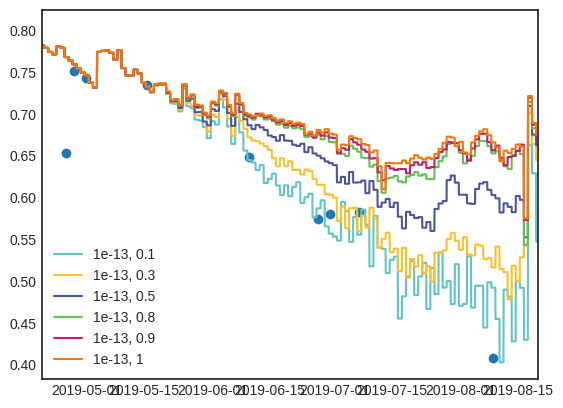

In [3]:
# al = Albedo('gulkana','D')
# ds = xr.open_dataset('../../Output/gulkanaD_2026_03_11_4.nc')
# al.get_model_albedo(ds)
# al.plot_timeseries()
# ds = best_dict['gulkana']['D']
# dates = pd.date_range('2019-04-20','2019-08-20')
# visualize_layers(ds, dates, ['layerwater','layergrainsize'])
for setno in range(2, 30, 5):
    fn_set = fp + fn.replace('XX', str(setno))
    if not os.path.exists(fn_set):
        continue
    ds = xr.open_dataset(fn_set).sel(time=slice('2019-04-20','2019-08-20'))
    plt.plot(ds.time, ds.albedo, label=ds.attrs['C1']+', '+ds.attrs['ksp_BC'], c=colors[setno//5])

    # if ds.attrs['C1'] == '1e-12' and ds.attrs['ksp_BC'] == '0.5':
    #     dates = pd.date_range('2019-04-20','2019-08-20')
    #     visualize_layers(ds, dates, ['layerwater','layergrainsize'])
plt.scatter(albedo_data.time, albedo_data.meas)
plt.xlim(pd.to_datetime('2019-04-20'), pd.to_datetime('2019-08-20'))
plt.legend()
plt.show()

In [4]:
import pickle
with open('best_datasets.pkl','wb') as f:
    pickle.dump(all_best, f)

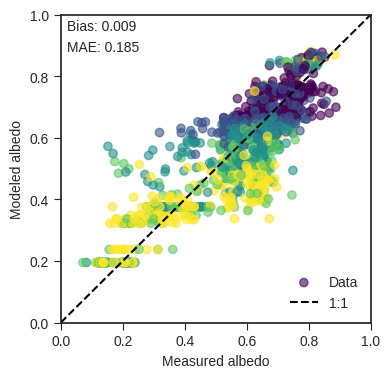

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

bias = np.nanmean(np.array(all_meas_albedo) - np.array(all_mod_albedo))
mae = np.nanmean(np.abs(np.array(all_meas_albedo) - np.array(all_mod_albedo)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Measured albedo')
plt.show()

In [2]:
import xarray as xr
xr.open_dataset('/trace/group/rounce/cvwilson/climate_data/UKESM/dr401_GFED/sum_bc_wetdeposition_kgm-2s-1.nc')

<xarray.Dataset> Size: 2GB
Dimensions:                                                                                              (
                                                                                                          time: 7030,
                                                                                                          latitude: 144,
                                                                                                          longitude: 192,
                                                                                                          bnds: 2)
Coordinates:
  * time                                                                                                 (time) datetime64[ns] 56kB ...
  * latitude                                                                                             (latitude) float32 576B ...
  * longitude                                                                                            (longitude) float32 768B ...
    forecast_reference_time                                                                              datetime64[ns] 8B ...
    level_height                                                                                         float64 8B ...
    model_level_number                                                                                   int64 8B ...
    sigma                                                                                                float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tendency_of_atmosphere_mass_content_of_elemental_carbon_dry_aerosol_particles_due_to_wet_deposition  (time, latitude, longitude) float64 2GB ...
    latitude_longitude                                                                                   int32 4B ...
    time_bnds                                                                                            (time, bnds) datetime64[ns] 112kB ...
    latitude_bnds                                                                                        (latitude, bnds) float32 1kB ...
    longitude_bnds                                                                                       (longitude, bnds) float64 3kB ...
    level_height_bnds                                                                                    (bnds) float64 16B ...
    sigma_bnds                                                                                           (bnds) float64 16B ...
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   13.5
    Conventions:  CF-1.7

In [25]:
all_df = None
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']

    dsu = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
    dsv = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
    wind = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    dsv.values = wind 
    all_wind = dsv.resample(time='d').mean()
    # glac_qms = {'taku':'lemon_creek','kennicott':'gulkana'}
    # glac_qm = glac_qms[glacier] if glacier in glac_qms else glacier
    # df_qm = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_{glac_qm}_wind.csv')
    # adj = np.interp(values, df_qm['sorted'], df_qm['mapping'])
    # dsv.values = adj 
    # wind = dsv.resample(time='d').mean()

    for site in site_dict[glacier]:
        # albedo = Albedo(glacier, site)
        ds = best_dict[glacier][site]
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        out = base_fp+f'ddf/{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc,  n_rolling_bc=5, n_rolling_pdds=1, savefig=True, output_fn=out) # , plot_corr=True,
        df['glacier'] = [glacier] * len(df.index)
        df['glaciersite'] = [glacier + site] * len(df.index)
        df['wind'] = all_wind.sel(time=pd.to_datetime(df.index)).values 
        if all_df is not None:
            all_df = pd.concat([all_df, df])
        else:
            all_df = df

/trace/home/cvwilson/miniconda3/envs/eb_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


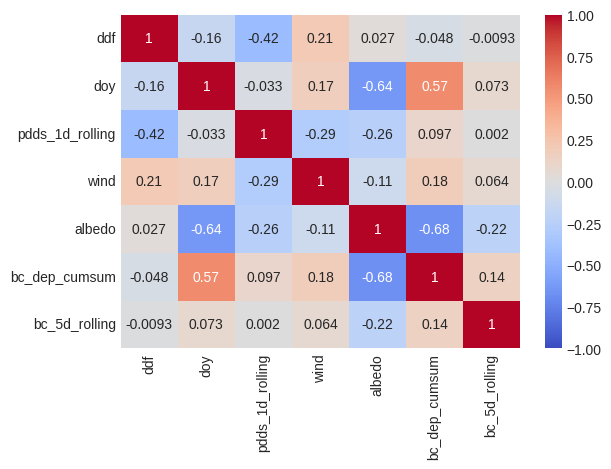

In [26]:
all_df['doy'] = pd.to_datetime(all_df.index).day_of_year
corr = all_df[['ddf','doy','pdds_1d_rolling','wind','albedo','bc_dep_cumsum','bc_5d_rolling']].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

In [27]:
import statsmodels.api as sm
# df['BC_eff'] = df['bc_1d_rolling'].ewm(halflife=3).mean()

# df must contain columns: 'melt', 'PDD', 'BC'
X = df[['pdds_1d_rolling', 'bc_5d_rolling']]
y = df['melt']

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.904
Model:                            OLS   Adj. R-squared (uncentered):              0.904
Method:                 Least Squares   F-statistic:                              4379.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:12:33   Log-Likelihood:                         -2988.1
No. Observations:                 933   AIC:                                      5980.
Df Residuals:                     931   BIC:                                      5990.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

/tmp/ipykernel_1065380/201218342.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


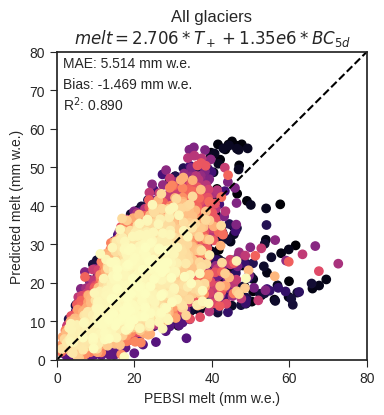

/tmp/ipykernel_1065380/201218342.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


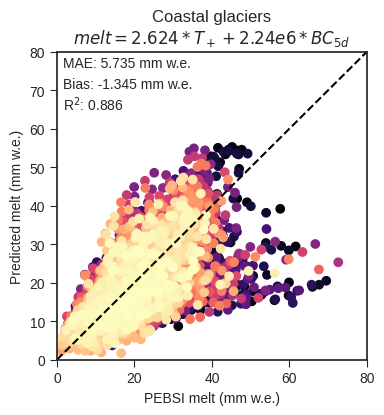

/tmp/ipykernel_1065380/201218342.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


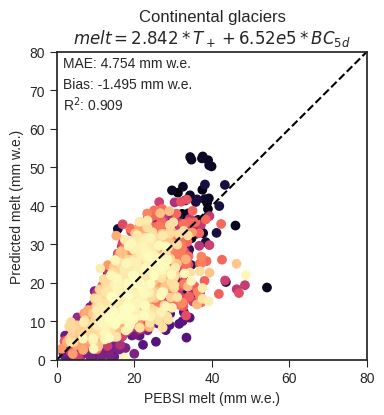

In [9]:
all_groups = {
          'all':['gulkana','wolverine','taku','kennicott','kahiltna','lemon_creek'], 
          'coastal':['wolverine','taku','lemon_creek'],
          'continental':['gulkana','kennicott','kahiltna'],
          }
for group in all_groups:
    glac_df = all_df.loc[all_df['glacier'].isin(all_groups[group])]
    X = glac_df[['pdds_1d_rolling', 'bc_5d_rolling']] # 
    y = glac_df['melt']

    model = sm.OLS(y, X).fit()

    ddf = model.params['pdds_1d_rolling']
    bcf = model.params['bc_5d_rolling']
    melt_predicted = glac_df['pdds_1d_rolling'] * ddf + glac_df['bc_5d_rolling'] * bcf
    melt_actual = glac_df['melt']

    x = melt_actual.values
    y = melt_predicted.values
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(melt_actual, melt_predicted, c=z, cmap='magma')
    ax.plot([0,80],[0,80],'k--')
    ax.legend()
    ax.tick_params(length=5)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 80)
    ax.set_xlabel('PEBSI melt (mm w.e.)')
    ax.set_ylabel('Predicted melt (mm w.e.)')
    ax.set_title(f'{group.capitalize()} glaciers\n$melt={ddf:.3f}*T_++{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}$')

    mae = np.nanmean(np.abs(melt_predicted - melt_actual))
    bias = np.nanmean(melt_predicted - melt_actual)
    r2 = model.rsquared
    ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

    plt.show()

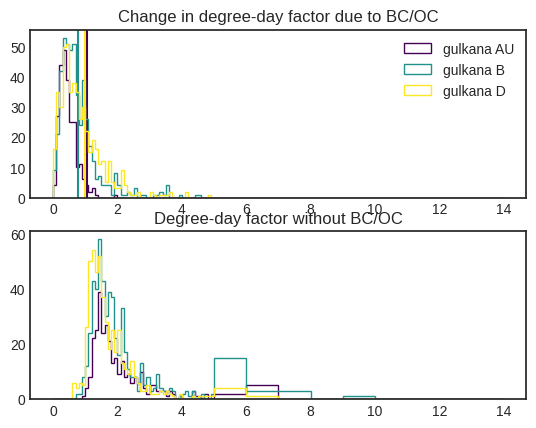

In [37]:
bins= np.concatenate([np.arange(0,5,0.1), np.arange(5, 15, 1)])
fig, (ax1, ax2) = plt.subplots(2)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=0, vmax=2)

i=0
n_rolling_BC = 7
df_change = None
for glacier in ['gulkana']:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(base_fp + f'/../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(base_fp + f'/../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    for site in site_dict[glacier]:
        # ds_base = best_dict[glacier][site]
        ds_base = xr.open_dataset(base_fp + 'ddf/' + glacier + site + '_2026_03_13_base_0.nc')
        df_base = get_ddf_df(ds_base, ds_bc, n_rolling_pdds=1, n_rolling_bc=n_rolling_BC)

        ds_noBCOC = xr.open_dataset(base_fp + 'ddf/' + glacier + site + '_2026_03_13_noBCOC_0.nc')
        df_noBCOC = get_ddf_df(ds_noBCOC, ds_bc, n_rolling_pdds=1, n_rolling_bc=n_rolling_BC)

        # f_snow = df_noBCOC['ddf'].copy()
        f_snow = df_noBCOC['melt'] / df_noBCOC['pdds_1d_rolling']
        fBC = (df_base['melt'] - f_snow*df_base['pdds_1d_rolling']) / (df_base['pdds_1d_rolling'])
        ax1.hist(fBC.values, bins=bins, histtype='step', edgecolor=cmap(norm(i)), label=glacier+' '+site)# colors[3])
        ax1.axvline(np.nanmean(fBC.values),color=cmap(norm(i)))
        ax1.set_title('Change in degree-day factor due to BC/OC')

        ax2.hist(f_snow, bins=bins, histtype='step', edgecolor=cmap(norm(i)))
        ax2.set_title(f'Degree-day factor without BC/OC')

        df = pd.DataFrame({'fBC':fBC, 
                           'snow_BC':df_base['snow_BC'],
                           f'bc_{n_rolling_BC}d_rolling':df_base[f'bc_{n_rolling_BC}d_rolling'],
                           'albedo':df_base['albedo'],
                           })
        if df_change is not None:
            df_change = df 
        else:
            df_change = pd.concat([df_change, df])

        i+= 1
ax1.legend()
plt.show()

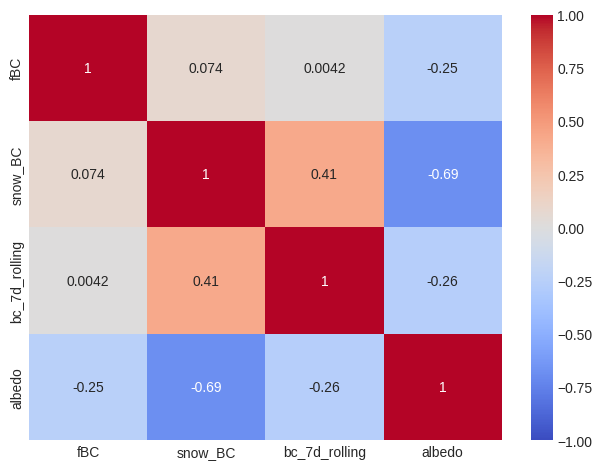

In [38]:
corr = df_change.corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

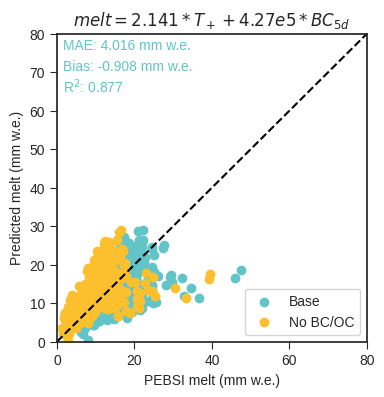

In [ ]:
glacier, site = 'gulkana', 'D'
ds_base = xr.open_dataset(base_fp + 'ddf/' + glacier + site + '_2026_03_13_base_0.nc')
df_base = get_ddf_df(ds_base, ds_bc, n_rolling_pdds=1, n_rolling_bc=5)

ds_noBCOC = xr.open_dataset(base_fp + 'ddf/' + glacier + site + '_2026_03_13_noBCOC_0.nc')
df_noBCOC = get_ddf_df(ds_noBCOC, ds_bc, n_rolling_pdds=1, n_rolling_bc=5)

X = df_base[['pdds_1d_rolling', 'bc_5d_rolling']] # 
y = df_base['melt']

model = sm.OLS(y, X).fit()

ddf = model.params['pdds_1d_rolling']
bcf = model.params['bc_5d_rolling']
melt_predicted = df_base['pdds_1d_rolling'] * ddf + df_base['bc_5d_rolling'] * bcf
melt_actual = df_base['melt']
melt_predicted_noBCOC = df_base['pdds_1d_rolling'] * ddf
melt_actual_noBCOC = df_noBCOC['melt']

# x = melt_actual_noBCOC.values
# y = melt_predicted_noBCOC.values
# xy = np.vstack([x, y])
# z = kde(xy)(xy)
# idx = z.argsort()
# x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(melt_actual, melt_predicted, c=colors[0], label='Base')
ax.scatter(melt_actual_noBCOC, melt_predicted_noBCOC, c=colors[1], label='No BC/OC') #  c=z, cmap='magma')
ax.plot([0,80],[0,80],'k--')
ax.legend(frameon=True)
ax.tick_params(length=5)
ax.set_xlim(0, 80)
ax.set_ylim(0, 80)
ax.set_xlabel('PEBSI melt (mm w.e.)')
ax.set_ylabel('Predicted melt (mm w.e.)')
ax.set_title(f'$melt={ddf:.3f}*T_++{bcf:.2e}*'.replace('e+0','e')+r'BC_{5d}$')

mae = np.nanmean(np.abs(melt_predicted - melt_actual))
bias = np.nanmean(melt_predicted - melt_actual)
r2 = model.rsquared
ax.text(0.02, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes, color=colors[0])
ax.text(0.02, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes, color=colors[0])
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes, color=colors[0])

mae = np.nanmean(np.abs(melt_predicted_noBCOC - melt_actual_noBCOC))
bias = np.nanmean(melt_predicted_noBCOC - melt_actual_noBCOC)
r2 = model.rsquared
ax.text(0.4, 0.95, f'MAE: {mae:.3f} mm w.e.', transform=ax.transAxes)
ax.text(0.4, 0.88, f'Bias: {bias:.3f} mm w.e.', transform=ax.transAxes)
ax.text(0.4, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

plt.show()